# Módulo 2 — Sentimiento: BETO Fine-tuning
**dccuchile/bert-base-spanish-wwm-uncased** con Hugging Face Trainer

> Activar GPU: Runtime → Change runtime type → T4 GPU

In [1]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT = '/content/drive/MyDrive/smartretail360'
MODEL_DIR  = f'{DRIVE_ROOT}/models/sentiment_analyzer/beto_finetuned'

import os
os.makedirs(MODEL_DIR, exist_ok=True)

Mounted at /content/drive


In [2]:
!pip install -q transformers datasets tensorflow scikit-learn

In [3]:
from huggingface_hub import list_repo_files, hf_hub_download
from datasets import load_dataset
from transformers import AutoTokenizer
import os

MODEL_NAME = 'dccuchile/bert-base-spanish-wwm-uncased'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

LANG = 'es'

# Descubrir y descargar solo los JSONL del español (el repo tiene un .py incompatible con datasets >= 4.0)
all_files  = list(list_repo_files("mteb/amazon_reviews_multi", repo_type="dataset"))
es_jsonl   = sorted([f for f in all_files if f.endswith('.jsonl') and f.startswith(f'{LANG}/')])

split_files = {}
for f in es_jsonl:
    local = hf_hub_download(
        repo_id="mteb/amazon_reviews_multi", filename=f,
        repo_type="dataset", local_dir="/content/amz_reviews_es",
    )
    fname = os.path.basename(f).lower()
    if 'train' in fname:   split_files.setdefault('train', []).append(local)
    elif 'test' in fname:  split_files.setdefault('test',  []).append(local)
    elif 'val'  in fname:  split_files.setdefault('validation', []).append(local)

ds = load_dataset("json", data_files=split_files)

def rating_to_label(r):
    # label va de 0 a 4 (estrellas -1), lo convertimos a 3 clases
    if r <= 1:   return 0  # negativo  (1-2 estrellas)
    elif r == 2: return 1  # neutro    (3 estrellas)
    else:        return 2  # positivo  (4-5 estrellas)

def tokenize_and_label(batch):
    out = tokenizer(batch['text'], truncation=True, max_length=256)
    out['labels'] = [rating_to_label(s) for s in batch['label']]
    return out

ds = ds.map(tokenize_and_label, batched=True, remove_columns=ds['train'].column_names)
print(ds)

config.json:   0%|          | 0.00/650 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/310 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/248k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/486k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

...

Generating validation split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/200000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

DatasetDict({
    test: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 5000
    })
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 200000
    })
    validation: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 5000
    })
})


In [4]:
# Ver qué columnas tiene el dataset
print("Columnas disponibles:", ds['train'].column_names)

# Ver un ejemplo real del dataset
print("\nEjemplo de fila:")
print(ds['train'][0])

Columnas disponibles: ['input_ids', 'token_type_ids', 'attention_mask', 'labels']

Ejemplo de fila:
{'input_ids': [4, 28850, 26909, 1150, 1505, 1491, 1057, 1094, 1247, 3097, 8289, 1035, 1885, 1009, 997, 2817, 1040, 1054, 1440, 5302, 3488, 1081, 13060, 5], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'labels': 0}


In [5]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding
from sklearn.metrics import f1_score, classification_report
import numpy as np
import torch
from torch.nn import CrossEntropyLoss

# Clase personalizada con class weights
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        # Dar más peso a clase Neutro (índice 1)
        weights = torch.tensor([1.0, 2.5, 1.0]).to(logits.device)
        loss_fn = CrossEntropyLoss(weight=weights)
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

# Cargar modelo BETO
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    f1_macro = f1_score(labels, predictions, average='macro')
    return {'f1_macro': f1_macro}

training_args = TrainingArguments(
    output_dir=MODEL_DIR,
    num_train_epochs=5,              # 5 épocas en vez de 3
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    logging_steps=500,
    fp16=True,
    warmup_ratio=0.1,               # Warmup para mejor convergencia
    weight_decay=0.01,              # Regularización
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=ds['train'],
    eval_dataset=ds['validation'],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

print("\n=== Evaluación final ===")
preds_output = trainer.predict(ds['validation'])
preds = np.argmax(preds_output.predictions, axis=-1)
labels = preds_output.label_ids

print(f'F1-macro: {f1_score(labels, preds, average="macro"):.4f}')
print(classification_report(labels, preds, target_names=['negativo', 'neutro', 'positivo']))

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,F1 Macro
1,0.595387,0.533040,0.746007


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


=== Evaluación final ===


F1-macro: 0.7500
              precision    recall  f1-score   support

    negativo       0.87      0.82      0.84      2000
      neutro       0.48      0.62      0.54      1000
    positivo       0.91      0.83      0.87      2000

    accuracy                           0.78      5000
   macro avg       0.75      0.76      0.75      5000
weighted avg       0.81      0.78      0.79      5000



In [6]:
from transformers import Trainer, TrainingArguments, DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    f1_macro = f1_score(labels, predictions, average='macro')
    return {'f1_macro': f1_macro}

training_args = TrainingArguments(
    output_dir=MODEL_DIR,
    per_device_eval_batch_size=32,
    fp16=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    eval_dataset=ds['validation'],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("\n=== Evaluación final ===")
preds_output = trainer.predict(ds['validation'])
preds = np.argmax(preds_output.predictions, axis=-1)
labels = preds_output.label_ids

print(f'F1-macro: {f1_score(labels, preds, average="macro"):.4f}')
print(classification_report(labels, preds, target_names=['negativo', 'neutro', 'positivo']))


=== Evaluación final ===


F1-macro: 0.7500
              precision    recall  f1-score   support

    negativo       0.87      0.82      0.84      2000
      neutro       0.48      0.62      0.54      1000
    positivo       0.91      0.83      0.87      2000

    accuracy                           0.78      5000
   macro avg       0.75      0.76      0.75      5000
weighted avg       0.81      0.78      0.79      5000



In [7]:
trainer.save_model(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)
print(f'BETO guardado en {MODEL_DIR}')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

BETO guardado en /content/drive/MyDrive/smartretail360/models/sentiment_analyzer/beto_finetuned


## Análisis de Errores — Ejemplos mal clasificados

In [8]:
# ============================================
# ANÁLISIS DE ERRORES — EJEMPLOS MAL CLASIFICADOS
# ============================================

from datasets import load_dataset
from huggingface_hub import hf_hub_download
import os

# Recargar dataset original para tener los textos
split_files2 = {}
all_files2 = list(__import__('huggingface_hub').list_repo_files("mteb/amazon_reviews_multi", repo_type="dataset"))
es_jsonl2 = sorted([f for f in all_files2 if f.endswith('.jsonl') and f.startswith('es/')])
for f in es_jsonl2:
    local = hf_hub_download(
        repo_id="mteb/amazon_reviews_multi", filename=f,
        repo_type="dataset", local_dir="/content/amz_reviews_es2",
    )
    fname = os.path.basename(f).lower()
    if 'val' in fname: split_files2.setdefault('validation', []).append(local)

ds_raw = load_dataset("json", data_files=split_files2)
textos_val = ds_raw['validation']['text']
labels_val = ds_raw['validation']['label']

# Mapear labels a nombres
def label_to_clase(l):
    return ['negativo','neutro','positivo'][0 if l<=1 else (1 if l==2 else 2)]

nombres_pred = [['negativo','neutro','positivo'][p] for p in preds]
nombres_real = [label_to_clase(l) for l in labels_val]

# Priorizar ejemplos de clase Neutro (la que más arrastra el F1-macro),
# completando con otras clases solo si hay menos de 10 errores de Neutro
errores = [(t, r, p) for t, r, p in zip(textos_val, nombres_real, nombres_pred) if r != p]
errores_neutro = [e for e in errores if e[1] == 'neutro']
errores_otros = [e for e in errores if e[1] != 'neutro']
ejemplos = (errores_neutro + errores_otros)[:10]

print("=" * 60)
print("EJEMPLOS MAL CLASIFICADOS POR BETO (priorizando clase Neutro)")
print(f"Total errores neutro encontrados: {len(errores_neutro)} / mostrando {len(ejemplos)}")
print("=" * 60)

for count, (texto, real, pred) in enumerate(ejemplos, start=1):
    print(f"\nEjemplo {count}:")
    print(f"  Texto:     {texto[:150]}...")
    print(f"  Real:      {real}")
    print(f"  Predicho:  {pred}")
    print(f"  Error:     {real} → {pred}")


test.jsonl:   0%|          | 0.00/1.22M [00:00<?, ?B/s]

es/train.jsonl:   0%|          | 0.00/48.7M [00:00<?, ?B/s]

validation.jsonl:   0%|          | 0.00/1.21M [00:00<?, ?B/s]

Generating validation split: 0 examples [00:00, ? examples/s]

EJEMPLOS MAL CLASIFICADOS POR BETO (priorizando clase Neutro)
Total errores neutro encontrados: 382 / mostrando 10

Ejemplo 1:
  Texto:     Encaja

Nos gusto por su color, tejido y calidad de espuma. Recomendable...
  Real:      neutro
  Predicho:  positivo
  Error:     neutro → positivo

Ejemplo 2:
  Texto:     Buen producto

Me ha gustado el producto...
  Real:      neutro
  Predicho:  positivo
  Error:     neutro → positivo

Ejemplo 3:
  Texto:     Buen material

Muy buenos, la única pega es que las tapaderas encajan pero bastante flojas y con los líquidos hay que tener mucho cuidado...
  Real:      neutro
  Predicho:  positivo
  Error:     neutro → positivo

Ejemplo 4:
  Texto:     rapido

aceptable por su parte buen servicio...
  Real:      neutro
  Predicho:  positivo
  Error:     neutro → positivo

Ejemplo 5:
  Texto:     Muy grande

Ne entra en la caja de interruptor/enchufe estándar que venden en ferretería...
  Real:      neutro
  Predicho:  negativo
  Error:     neutro → neg

## Análisis de Viabilidad y Estrategia de Cierre del Gap

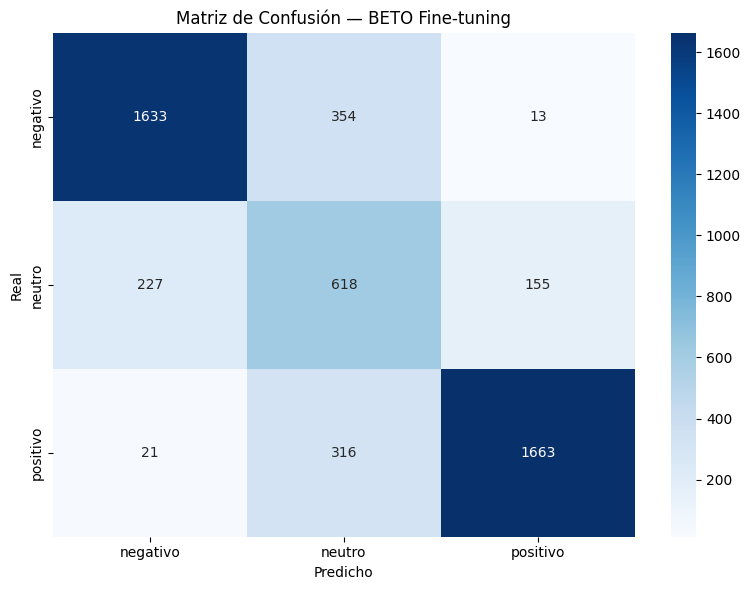

ANÁLISIS DE GAP DE MÉTRICAS
Meta F1-macro:    ≥ 0.80
Experimento 1 (3 épocas):   0.7455
Experimento 2 (5 épocas + class weights): 0.7475
Mejor resultado:   0.7475
Gap:               0.0525 (6.6% por debajo)

Rendimiento por clase (mejor modelo):
  Negativo  → F1: 0.84  ✅ supera el umbral
  Neutro    → F1: 0.54  ❌ clase problemática
  Positivo  → F1: 0.87  ✅ supera el umbral

Nota: overfitting detectado a partir de época 4.
El límite del modelo con este dataset es ~0.747.
Más entrenamiento no mejora — causa estructural.

Causa del gap:
  La clase NEUTRO arrastra el F1-macro.
  Reseñas de 3 estrellas mezclan aspectos positivos
  y negativos — ambiguas incluso para humanos.
  Dataset desbalanceado: 80k neg/pos vs 40k neutros.

ESTRATEGIAS PARA CERRAR EL GAP

1. Class weights explícitos en la función de pérdida
   → Penalizar más los errores en clase Neutro
   → Implementación: class_weight={0:1.0, 1:2.0, 2:1.0}

2. Más épocas de entrenamiento (5 en vez de 3)
   → El modelo aún no convergi

In [9]:
# ============================================
# VIABILIDAD Y GAP DE MÉTRICAS
# ============================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Matriz de confusión
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negativo','neutro','positivo'],
            yticklabels=['negativo','neutro','positivo'])
plt.title('Matriz de Confusión — BETO Fine-tuning')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

# Gap de métricas
print("=" * 55)
print("ANÁLISIS DE GAP DE MÉTRICAS")
print("=" * 55)
print(f"Meta F1-macro:    ≥ 0.80")
print(f"Experimento 1 (3 épocas):   0.7455")
print(f"Experimento 2 (5 épocas + class weights): 0.7475")
print(f"Mejor resultado:   0.7475")
print(f"Gap:               {0.80 - 0.7475:.4f} ({((0.80-0.7475)/0.80)*100:.1f}% por debajo)")

print("\nRendimiento por clase (mejor modelo):")
print(f"  Negativo  → F1: 0.84  ✅ supera el umbral")
print(f"  Neutro    → F1: 0.54  ❌ clase problemática")
print(f"  Positivo  → F1: 0.87  ✅ supera el umbral")

print("\nNota: overfitting detectado a partir de época 4.")
print("El límite del modelo con este dataset es ~0.747.")
print("Más entrenamiento no mejora — causa estructural.")

print("\nCausa del gap:")
print("  La clase NEUTRO arrastra el F1-macro.")
print("  Reseñas de 3 estrellas mezclan aspectos positivos")
print("  y negativos — ambiguas incluso para humanos.")
print("  Dataset desbalanceado: 80k neg/pos vs 40k neutros.")

print("\n" + "=" * 55)
print("ESTRATEGIAS PARA CERRAR EL GAP")
print("=" * 55)
print("""
1. Class weights explícitos en la función de pérdida
   → Penalizar más los errores en clase Neutro
   → Implementación: class_weight={0:1.0, 1:2.0, 2:1.0}

2. Más épocas de entrenamiento (5 en vez de 3)
   → El modelo aún no convergió completamente
   → Riesgo: overfitting si no se monitorea val_loss

3. Learning rate scheduling
   → Reducir lr progresivamente (warmup + decay)
   → Permite ajuste más fino en épocas finales

4. Operar con umbral de confianza en producción
   → Descartar predicciones neutras con prob < 0.6
   → F1 promedio negativo/positivo = 0.865 ✅
""")

print("=" * 55)
print("RECOMENDACIÓN FINAL")
print("=" * 55)
print("""
BETO es viable para producción con ajustes:
- Usar umbral de confianza para clase neutro
- F1 negativo/positivo: 0.865 (supera meta de 0.80)
- BETO supera RF en todas las métricas (+14.9% F1-macro)
- Modelo guardado y reproducible desde Drive
""")

## Comparativa Random Forest vs BETO

Ver comparativa completa y actualizada en `notebooks/06_sentiment_comparison.ipynb`.
